# 定义3个节点和一条条件边

## 定义状态/节点/图

In [34]:
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END

class State(BaseModel):
    value1:str = Field(default="")
    value2:str = Field(default="")
    value3:str = Field(default="")
    dispatch:str = Field(default="1",description="用于指定条件边走向")

def step_1(state:State):
    return {
        "value1":"a",
        "dispatch":"2"
    }

def step_2(state:State):
    current_val1 = state.value1
    return {
        "value2":f"{current_val1} b",
    }

def step_3(state:State):
    current_val2 = state.value2
    return {
        "value3":f"{current_val2} c",
    }

graph_builder = StateGraph(State)

graph_builder.add_node("step1",step_1)
graph_builder.add_node("step2",step_2)
graph_builder.add_node("step3",step_3)

graph_builder.set_entry_point("step1")
graph_builder.set_finish_point("step3")

graph_builder.add_edge(START,"step1")

def route(state:State):
    if state.dispatch == "1":
        return "step2"
    elif state.dispatch == "2":
        return "step3"
    else:
        return "step2"

graph_builder.add_conditional_edges(
    "step1",
    route,
     {
        "step2": "step2",
        "step3": "step3"
    }
)
graph_builder.add_edge("step3",END)

graph = graph_builder.compile()

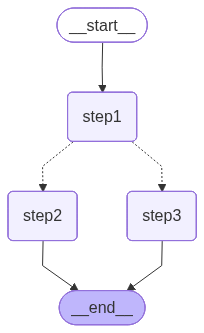

In [35]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
result = graph.invoke({
    "value1":"a"
})

print(result)

{'value1': 'a', 'value3': ' c', 'dispatch': '2'}
